# ETL + Data Warehouse de  World Development Indicators (WDI)
# Integrantes: 
* Rodrigo Andres Gomez Lopez
* Brayan Gonzales


# 1. Introducción al Proyecto

Este proyecto consiste en construir un proceso ETL completo usando datos del Banco Mundial (World Development Indicators).

La idea es migrar datos desde un archivo CSV hacia MySQL, transformarlos, organizarlos en un modelo dimensional (esquema estrella) y luego analizarlos mediante consultas SQL tipo OLAP y visualizaciones.

Aquí no solo se trata de hacer gráficos, sino de estructurar los datos como se haría en un entorno real de Data Engineering:

- Cargar datos crudos (staging)
- Limpiarlos y transformarlos
- Diseñar dimensiones y tabla de hechos
- Validar integridad del modelo
- Generar análisis directamente desde el Data Warehouse

El resultado final no es solo un análisis visual, sino un Data Warehouse funcional y consistente.

# 2. Requirements Gathering y SDG

##  Objetivo del Proyecto

El objetivo principal es diseñar e implementar un pipeline ETL completo que permita analizar indicadores globales del Banco Mundial, con énfasis en métricas relacionadas con salud y desarrollo.

El proyecto incluye:

- Migración de datos desde CSV hacia MySQL.
- Transformación y limpieza de datos.
- Diseño de un modelo dimensional (esquema estrella).
- Validación de integridad referencial.
- Análisis OLAP mediante consultas SQL.
- Visualización de resultados desde el Data Warehouse.

---

## Preguntas que queremos responder

1. ¿Cómo ha cambiado la esperanza de vida promedio a nivel global con el tiempo?
2. ¿Qué indicadores tienen mayor cobertura y calidad dentro del dataset?
3. ¿Cómo se comporta Colombia comparada con el promedio mundial?
4. ¿Existen diferencias entre esperanza de vida masculina y femenina?

---

## Alineación con los ODS (SDG)

Este análisis está alineado principalmente con el **ODS 3: Salud y Bienestar**, ya que se estudian indicadores como:

- Esperanza de vida al nacer (total, femenina y masculina)
- Tasa de fertilidad
- Tasa de mortalidad

Estos indicadores reflejan directamente condiciones de salud, calidad de vida y desarrollo humano a nivel global.

El uso de un modelo estrella permite estructurar estos datos de manera organizada y eficiente para su análisis.

#3. Evaluación de la Fuente de Datos


Seleccionamos el dataset **World Development Indicators (WDI)** del Banco Mundial porque:

- Es de acceso público.
- Tiene datos históricos desde 1960.
- Contiene indicadores relevantes para temas sociales y económicos.
- Está en formato CSV, lo que facilita el proceso ETL.
- Tiene valores faltantes (lo cual es normal en datos globales y será parte del análisis).

El archivo utilizado es: `WDI_10k_AGL.csv`

#4. Arquitectura ETL y Stack Tecnológico

* Arquitectura del Proyecto

El flujo del proyecto es el siguiente:

1. CSV (fuente)
2. Carga en MySQL como tabla RAW
3. Transformación (wide → long)
4. Carga limpia en MySQL
5. Modelado dimensional (Data Warehouse estrella)
6. Consultas SQL
7. Visualizaciones en Python

---

* Stack Tecnológico

- Python (ETL y análisis)
- Pandas (transformaciones)
- MySQL (base de datos relacional)
- Matplotlib (visualizaciones)
- Jupyter Notebook (documentación del proceso)
- GitHub (control de versiones)

#5. Conexión a MySQL

Aquí establezcemos la conexión con la base de datos donde se almacenarán los datos.

In [25]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine(
    "mysql+pymysql://root:@127.0.0.1:3306/wdi_etl_db?charset=utf8mb4"
)

print("Conexión creada correctamente")

Conexión creada correctamente


6. Carga del CSV

* Extracción de Datos (Extract)

Cargo el archivo CSV en un DataFrame para comenzar el proceso ETL.

In [26]:
df = pd.read_csv("../data/raw/WDI_10k_AGL.csv")
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (10000, 69)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.145833,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.259936,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.741988,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,16.495064,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.747222,35.240236,NaN


7. Migración a MySQL - RAW Layer

* Carga a la Base de Datos (RAW)

Aquí cargo el dataset tal cual viene a MySQL.  
Esto es importante porque en un ETL real siempre se guarda una versión cruda antes de transformar.

In [27]:
df.to_sql("wdi_raw", engine, if_exists="replace", index=False)

resultado = pd.read_sql("SELECT COUNT(*) AS total_filas FROM wdi_raw;", engine)
resultado

,total_filas
0,10000


#8. Transformación  - Wide a Long

El dataset original viene en formato ancho (cada año como columna).  
Para analizar correctamente los datos, lo convierto a formato largo (tidy data).

In [28]:
df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
df_long = df_long.dropna(subset=["Year"])
df_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN


#9. Carga Limpia en MySQL

Guardo la versión transformada como `wdi_clean`.  
Esta tabla será la base para el modelado dimensional.

In [29]:
df_long.to_sql("wdi_clean", engine, if_exists="replace", index=False)

pd.read_sql("SELECT COUNT(*) AS total_filas FROM wdi_clean;", engine)

,total_filas
0,650000


# 10. Análisis Exploratorio EDA

Ahora comienzo a explorar los datos directamente desde la base de datos usando consultas SQL.

In [30]:
pd.read_sql("""
SELECT COUNT(*) AS total_registros,
SUM(Value IS NULL) AS valores_nulos,
SUM(Value IS NOT NULL) AS valores_validos
FROM wdi_clean;
""", engine)

,total_registros,valores_nulos,valores_validos
0,650000,455494.0,194506.0


10.1 Inform de analisis EDA

Se puede ver que hay bastantes valores nulos, lo cual tiene sentido porque no todos los países reportan todos los indicadores cada año.  

Esto es normal en datasets globales y no significa que los datos estén mal, simplemente hay cobertura parcial.

#11. Visualización Global

* Promedio Global por Año

Voy a calcular el promedio global de los valores por año.

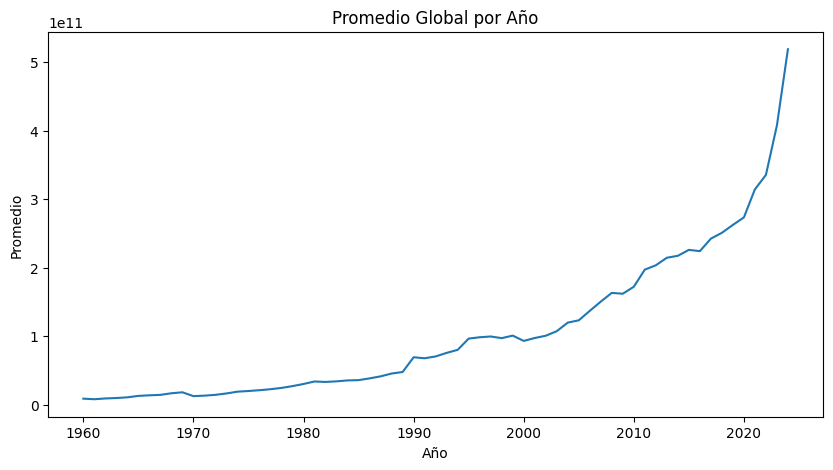

In [31]:
import matplotlib.pyplot as plt

df_avg = pd.read_sql("""
SELECT Year, AVG(Value) AS promedio
FROM wdi_clean
WHERE Value IS NOT NULL
GROUP BY Year
ORDER BY Year;
""", engine)

plt.figure(figsize=(10,5))
plt.plot(df_avg["Year"], df_avg["promedio"])
plt.title("Promedio Global por Año")
plt.xlabel("Año")
plt.ylabel("Promedio")
plt.show()

11.1 Analisis visualizacion

Se observa una tendencia creciente a lo largo del tiempo.  

Eso indica que muchos indicadores globales han ido mejorando progresivamente.

#12 Modelo Dimensional - Data Warehouse

* Modelado Dimensional (Modelo Estrella)

Ahora organizo los datos en un modelo estrella para facilitar consultas analíticas.

12.1 Crear dimensiones desde MySQL



12.1.1 Crear la dimensión `dim_country` 

Aquí voy a crear la tabla de dimensión de países en MySQL.

Esta parte no es una consulta tipo “SELECT”, sino comandos de base de datos (DROP, CREATE, ALTER).  
Por eso NO se puede usar `pd.read_sql()` en estas líneas, porque pandas espera que la consulta devuelva una tabla como resultado.

Entonces lo hacemos con una conexión directa (`engine.begin()`), que es lo correcto para ejecutar SQL de creación de tablas.

In [35]:
from sqlalchemy import text

with engine.begin() as conn:
    # 1) Borrar si existe
    conn.execute(text("DROP TABLE IF EXISTS dim_country;"))

    # 2) Crear dimensión desde wdi_clean
    conn.execute(text("""
        CREATE TABLE dim_country AS
        SELECT DISTINCT
            `Country Code` AS country_code,
            `Country Name` AS country_name
        FROM wdi_clean;
    """))

    # 3) Agregar surrogate key (PK)
    conn.execute(text("""
        ALTER TABLE dim_country
        ADD COLUMN country_key INT AUTO_INCREMENT PRIMARY KEY FIRST;
    """))

print("dim_country creada correctamente")
pd.read_sql("SELECT * FROM dim_country LIMIT 5;", engine)

dim_country creada correctamente


,country_key,country_code,country_name
0,1,AFE,Africa Eastern and Southern
1,2,AFW,Africa Western and Central
2,3,ARB,Arab World
3,4,CSS,Caribbean small states
4,5,CEB,Central Europe and the Baltics


12.1.2 Crear la dimensión `dim_indicator`

Ahora creo la dimensión de indicadores.  

La idea es guardar la parte “descriptiva” (nombre y código del indicador) en una tabla separada, y asignarle una clave (indicator_key) para conectarla con la tabla de hechos.

In [37]:
from sqlalchemy import text

with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS dim_indicator;"))

    conn.execute(text("""
        CREATE TABLE dim_indicator AS
        SELECT DISTINCT
            `Indicator Code` AS indicator_code,
            `Indicator Name` AS indicator_name
        FROM wdi_clean;
    """))

    conn.execute(text("""
        ALTER TABLE dim_indicator
        ADD COLUMN indicator_key INT AUTO_INCREMENT PRIMARY KEY FIRST;
    """))

print("dim_indicator creada correctamente")
pd.read_sql("SELECT * FROM dim_indicator LIMIT 5;", engine)

dim_indicator creada correctamente


,indicator_key,indicator_code,indicator_name
0,1,EG.CFT.ACCS.ZS,Access to clean fuels and technologies for coo...
1,2,EG.CFT.ACCS.RU.ZS,Access to clean fuels and technologies for coo...
2,3,EG.CFT.ACCS.UR.ZS,Access to clean fuels and technologies for coo...
3,4,EG.ELC.ACCS.ZS,Access to electricity (% of population)
4,5,EG.ELC.ACCS.RU.ZS,"Access to electricity, rural (% of rural popul..."


12.1.3 Crear la dimensión `dim_date`

Aquí creo la dimensión de tiempo.  

En este dataset solo tenemos el año, pero igual sirve para hacer análisis históricos y mantener el modelo estrella organizado.

In [38]:
from sqlalchemy import text

with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS dim_date;"))

    conn.execute(text("""
        CREATE TABLE dim_date AS
        SELECT DISTINCT
            Year
        FROM wdi_clean
        WHERE Year IS NOT NULL;
    """))

    conn.execute(text("""
        ALTER TABLE dim_date
        ADD COLUMN date_key INT AUTO_INCREMENT PRIMARY KEY FIRST;
    """))

print("dim_date creada correctamente")
pd.read_sql("SELECT * FROM dim_date ORDER BY Year LIMIT 5;", engine)

dim_date creada correctamente


,date_key,Year
0,1,1960
1,2,1961
2,3,1962
3,4,1963
4,5,1964


12.2 Crear tabla hechos

* Crear la tabla de hechos del modelo estrella

En este bloque voy a construir la tabla de hechos (`fact_wdi`) pero de una manera más segura y controlada.

En vez de hacer un JOIN gigante directamente en MySQL (que puede bloquear la base cuando hay muchos datos), traigo primero la información necesaria a pandas y hago los `merge` aquí.

Aqui lo que se hace es:

1. Traigo solo las columnas importantes desde `wdi_clean` (país, indicador, año y valor).
2. Traigo las dimensiones (`dim_country`, `dim_indicator`, `dim_date`) que ya tienen sus llaves primarias.
3. Hago los `merge` en pandas para conectar todo usando las llaves correctas.
4. Me quedo solo con las columnas finales del modelo estrella:
   - `country_key`
   - `indicator_key`
   - `date_key`
   - `Value`
5. Finalmente, subo el resultado ya limpio a MySQL como `fact_wdi`.


* ¿Por qué lo hago así?

Porque:
- Es más estable.
- Evita que MySQL se congele.
- Me permite controlar el tamaño del DataFrame antes de enviarlo a la base.
- Cumple perfectamente con el diseño de un **Data Warehouse en esquema estrella**.

Al final, ya tengo una tabla de hechos real, conectada con sus dimensiones, lista para hacer análisis tipo OLAP.

In [5]:
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+pymysql://root:@127.0.0.1:3306/wdi_etl_db?charset=utf8mb4" 
)

print("Conexión creada nuevamente")

Conexión creada nuevamente


In [11]:
import pandas as pd


df_wc = pd.read_sql("""
SELECT `Country Code`, `Indicator Code`, Year, Value
FROM wdi_clean
WHERE Value IS NOT NULL;
""", engine)

df_country = pd.read_sql("SELECT country_key, country_code FROM dim_country;", engine)
df_indicator = pd.read_sql("SELECT indicator_key, indicator_code FROM dim_indicator;", engine)
df_date = pd.read_sql("SELECT date_key, Year FROM dim_date;", engine)

print("Datos cargados desde la base")


df_fact = (
    df_wc
    .merge(df_country, left_on="Country Code", right_on="country_code")
    .merge(df_indicator, left_on="Indicator Code", right_on="indicator_code")
    .merge(df_date, on="Year")
)


df_fact = df_fact[["country_key", "indicator_key", "date_key", "Value"]]

print("Dimensiones fact:", df_fact.shape)


df_fact.to_sql("fact_wdi", engine, if_exists="replace", index=False)

print(" fact_wdi creada correctamente")

Datos cargados desde la base
Dimensiones fact: (194506, 4)
 fact_wdi creada correctamente


12.2.1 Crear índices en la tabla de hechos

Como la tabla de hechos ya tiene 194k filas, si hacemos consultas sin índices puede ponerse lenta.

Entonces creo índices en las llaves (country_key, indicator_key, date_key) para que los filtros y joins vuelen.

In [12]:
from sqlalchemy import text

with engine.begin() as conn:
    conn.execute(text("CREATE INDEX idx_fact_country ON fact_wdi(country_key);"))
    conn.execute(text("CREATE INDEX idx_fact_indicator ON fact_wdi(indicator_key);"))
    conn.execute(text("CREATE INDEX idx_fact_date ON fact_wdi(date_key);"))

print("Índices creados en fact_wdi")

Índices creados en fact_wdi


12.2.2 Chequeo rápido de integridad  para ver que no haya llaves nulas

* Revisar que el modelo estrella quedó bien

Aquí reviso que no haya llaves nulas en la tabla de hechos.
Si sale todo en 0, significa que el merge con las dimensiones quedó limpio y consistente.

In [13]:
import pandas as pd

pd.read_sql("""
SELECT
  SUM(country_key IS NULL) AS null_country_key,
  SUM(indicator_key IS NULL) AS null_indicator_key,
  SUM(date_key IS NULL) AS null_date_key,
  SUM(Value IS NULL) AS null_value,
  COUNT(*) AS total_rows
FROM fact_wdi;
""", engine)

,null_country_key,null_indicator_key,null_date_key,null_value,total_rows
0,0.0,0.0,0.0,0.0,194506


12.2.3 OLAP real con el Top 10 indicadores con más datos

* Mirar qué indicadores tienen más datos (modo OLAP)

Como ya estamos en esquema estrella, puedo hacer análisis tipo OLAP:
ver cuáles indicadores tienen más registros válidos dentro del DW.
Eso me ayuda a elegir buenos indicadores para gráficas (los que no están súper vacíos).

In [14]:
pd.read_sql("""
SELECT 
  i.indicator_name,
  COUNT(*) AS registros
FROM fact_wdi f
JOIN dim_indicator i ON f.indicator_key = i.indicator_key
GROUP BY i.indicator_name
ORDER BY registros DESC
LIMIT 10;
""", engine)

,indicator_name,registros
0,Age dependency ratio (% of working-age populat...,455
1,"Age dependency ratio, old (% of working-age po...",455
2,"Age dependency ratio, young (% of working-age ...",455
3,"Adolescent fertility rate (births per 1,000 wo...",448
4,"Birth rate, crude (per 1,000 people)",448
5,"Death rate, crude (per 1,000 people)",448
6,"Fertility rate, total (births per woman)",448
7,"Life expectancy at birth, female (years)",448
8,"Life expectancy at birth, male (years)",448
9,"Life expectancy at birth, total (years)",448


12.2.3.1 Análisis OLAP – Indicadores con mayor cobertura

El análisis muestra que los indicadores con más registros están principalmente relacionados con variables demográficas y de salud, como:

- Razón de dependencia poblacional
- Tasa de fertilidad
- Tasa de natalidad y mortalidad
- Esperanza de vida (total, femenina y masculina)

Todos estos indicadores tienen entre 448 y 455 registros válidos dentro del Data Warehouse.

Esto es positivo porque indica que estos indicadores tienen buena cobertura dentro del dataset seleccionado y son adecuados para análisis temporales y comparativos.

Además, varios de ellos están directamente alineados con el ODS 3 (Salud y Bienestar), lo cual refuerza la coherencia del proyecto con los objetivos de desarrollo sostenible.

12.2.4 Elegir un indicador  para graficar tendencia por año

Ahora selecciono un indicador que tenga muchos registros (porque así la gráfica sale más completa).
En la práctica, elijo uno del TOP anterior y hago el promedio por año.

In [15]:
indicador = "Life expectancy at birth, total (years)"  

df_trend = pd.read_sql(f"""
SELECT 
  d.Year,
  AVG(f.Value) AS avg_value
FROM fact_wdi f
JOIN dim_date d ON f.date_key = d.date_key
JOIN dim_indicator i ON f.indicator_key = i.indicator_key
WHERE i.indicator_name = "{indicador}"
GROUP BY d.Year
ORDER BY d.Year;
""", engine)

df_trend.head()

,Year,avg_value
0,1960,49.086296
1,1961,50.102298
2,1962,51.400641
3,1963,51.951395
4,1964,52.408609


12.2.4.1 Análisis del indicador estrella por año

La tabla muestra el promedio mundial de la esperanza de vida al nacer para cada año.

Se puede observar que desde 1960 el valor aumenta de forma progresiva, pasando de aproximadamente 49 años en 1960 a más de 52 años en 1964, lo cual evidencia una tendencia positiva en las condiciones de salud globales.

Este resultado es relevante porque:

- Fue calculado directamente desde el Data Warehouse (modelo estrella).
- Utiliza la tabla de hechos y las dimensiones.
- Representa un análisis tipo OLAP real.

La tendencia creciente refleja mejoras en medicina, nutrición y condiciones de vida a nivel global durante las últimas décadas.

12.2.4.2 Visualización del promedio mundial de esperanza de vida

En este bloque estoy graficando la evolución del promedio mundial de la esperanza de vida a lo largo del tiempo.

Los datos no vienen directamente del CSV, sino del **Data Warehouse**, específicamente de:

- La tabla de hechos `fact_wdi`
- Las dimensiones `dim_date` y `dim_indicator`

Primero calculé el promedio por año usando una consulta SQL (análisis tipo OLAP), y luego utilicé `matplotlib` para visualizar la tendencia.



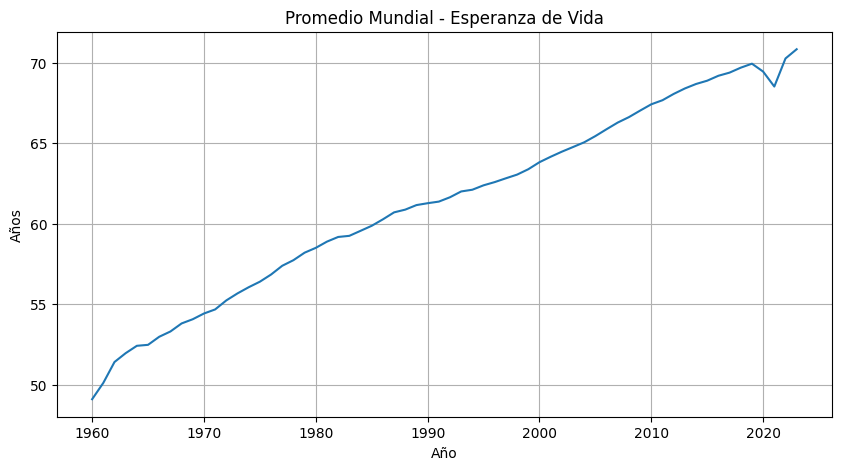

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_trend["Year"], df_trend["avg_value"])
plt.title("Promedio Mundial - Esperanza de Vida")
plt.xlabel("Año")
plt.ylabel("Años")
plt.grid(True)
plt.show()

12.2.4.3 Analisis grafica

Se observa una tendencia claramente creciente desde 1960 hasta la actualidad:

- En 1960 el promedio mundial estaba alrededor de 49 años.
- Con el paso de las décadas, la línea sube de manera constante.
- En los años recientes supera los 70 años.
- Se nota una pequeña caída alrededor de 2020, probablemente asociada a eventos globales como la pandemia.


Esta gráfica demuestra que:

- El modelo estrella funciona correctamente.
- El análisis se está haciendo desde la base de datos.
- El Data Warehouse permite estudiar tendencias históricas de manera estructurada.
- Existe una mejora sostenida en las condiciones de salud global a lo largo del tiempo.

En resumen, el Data Warehouse no solo almacena datos, sino que permite generar conocimiento a partir de ellos.

# 13. MODELO ENTIDAD RELACION


Antes de armar el Data Warehouse, necesito dejar claro cómo están los datos “en crudo / limpios” en la base.  
En nuestro caso, el modelo relacional de origen se resume en la tabla `wdi_clean`, que es donde quedan los datos limpios listos para transformar.

La idea de este diagrama es mostrar el **punto de partida** (origen) antes de pasar al modelo estrella, para que se entienda el flujo:  

**CSV → wdi_raw → wdi_clean → (dimensiones + hechos)**

In [19]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

# Carpeta destino para imágenes
ruta_base = "../"  # notebook está en /notebooks
img_dir = os.path.join(ruta_base, "docs", "imagenes")
os.makedirs(img_dir, exist_ok=True)

ruta_img_relacional = os.path.join(img_dir, "modelo_relacional.png")

# --- Figura
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axis_off()

def draw_table(ax, x, y, w, h, title, rows, header_color="#dddddd"):
    # caja exterior
    ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=2))
    # header
    header_h = 0.12 * h
    ax.add_patch(Rectangle((x, y + h - header_h), w, header_h, fill=True, color=header_color, linewidth=2))
    ax.text(x + w/2, y + h - header_h/2, title, ha="center", va="center", fontsize=12, fontweight="bold")
    # filas
    row_h = (h - header_h) / max(len(rows), 1)
    for i, r in enumerate(rows):
        yy = y + h - header_h - (i+1)*row_h
        ax.plot([x, x+w], [yy, yy], color="black", linewidth=1)
        ax.text(x + 0.02*w, yy + row_h/2, r, ha="left", va="center", fontsize=10)

def arrow(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="->", mutation_scale=15, linewidth=2))

# Tablas origen
rows_raw = [
    "Country Name",
    "Country Code",
    "Indicator Name",
    "Indicator Code",
    "1960 ... 2024 (columnas año)"
]
rows_clean = [
    "Country Code",
    "Country Name",
    "Indicator Code",
    "Indicator Name",
    "Year",
    "Value",
    "PK lógica: (Country Code, Indicator Code, Year)"
]

draw_table(ax, 0.08, 0.20, 0.35, 0.60, "wdi_raw (staging)", rows_raw)
draw_table(ax, 0.57, 0.20, 0.35, 0.60, "wdi_clean (relacional limpio)", rows_clean)

# Flecha
arrow(ax, 0.43, 0.50, 0.57, 0.50)
ax.text(0.50, 0.54, "Limpieza / Transformación", ha="center", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(ruta_img_relacional, dpi=200, bbox_inches="tight")
plt.close()

print("Imagen creada:", ruta_img_relacional)

Imagen creada: ../docs\imagenes\modelo_relacional.png


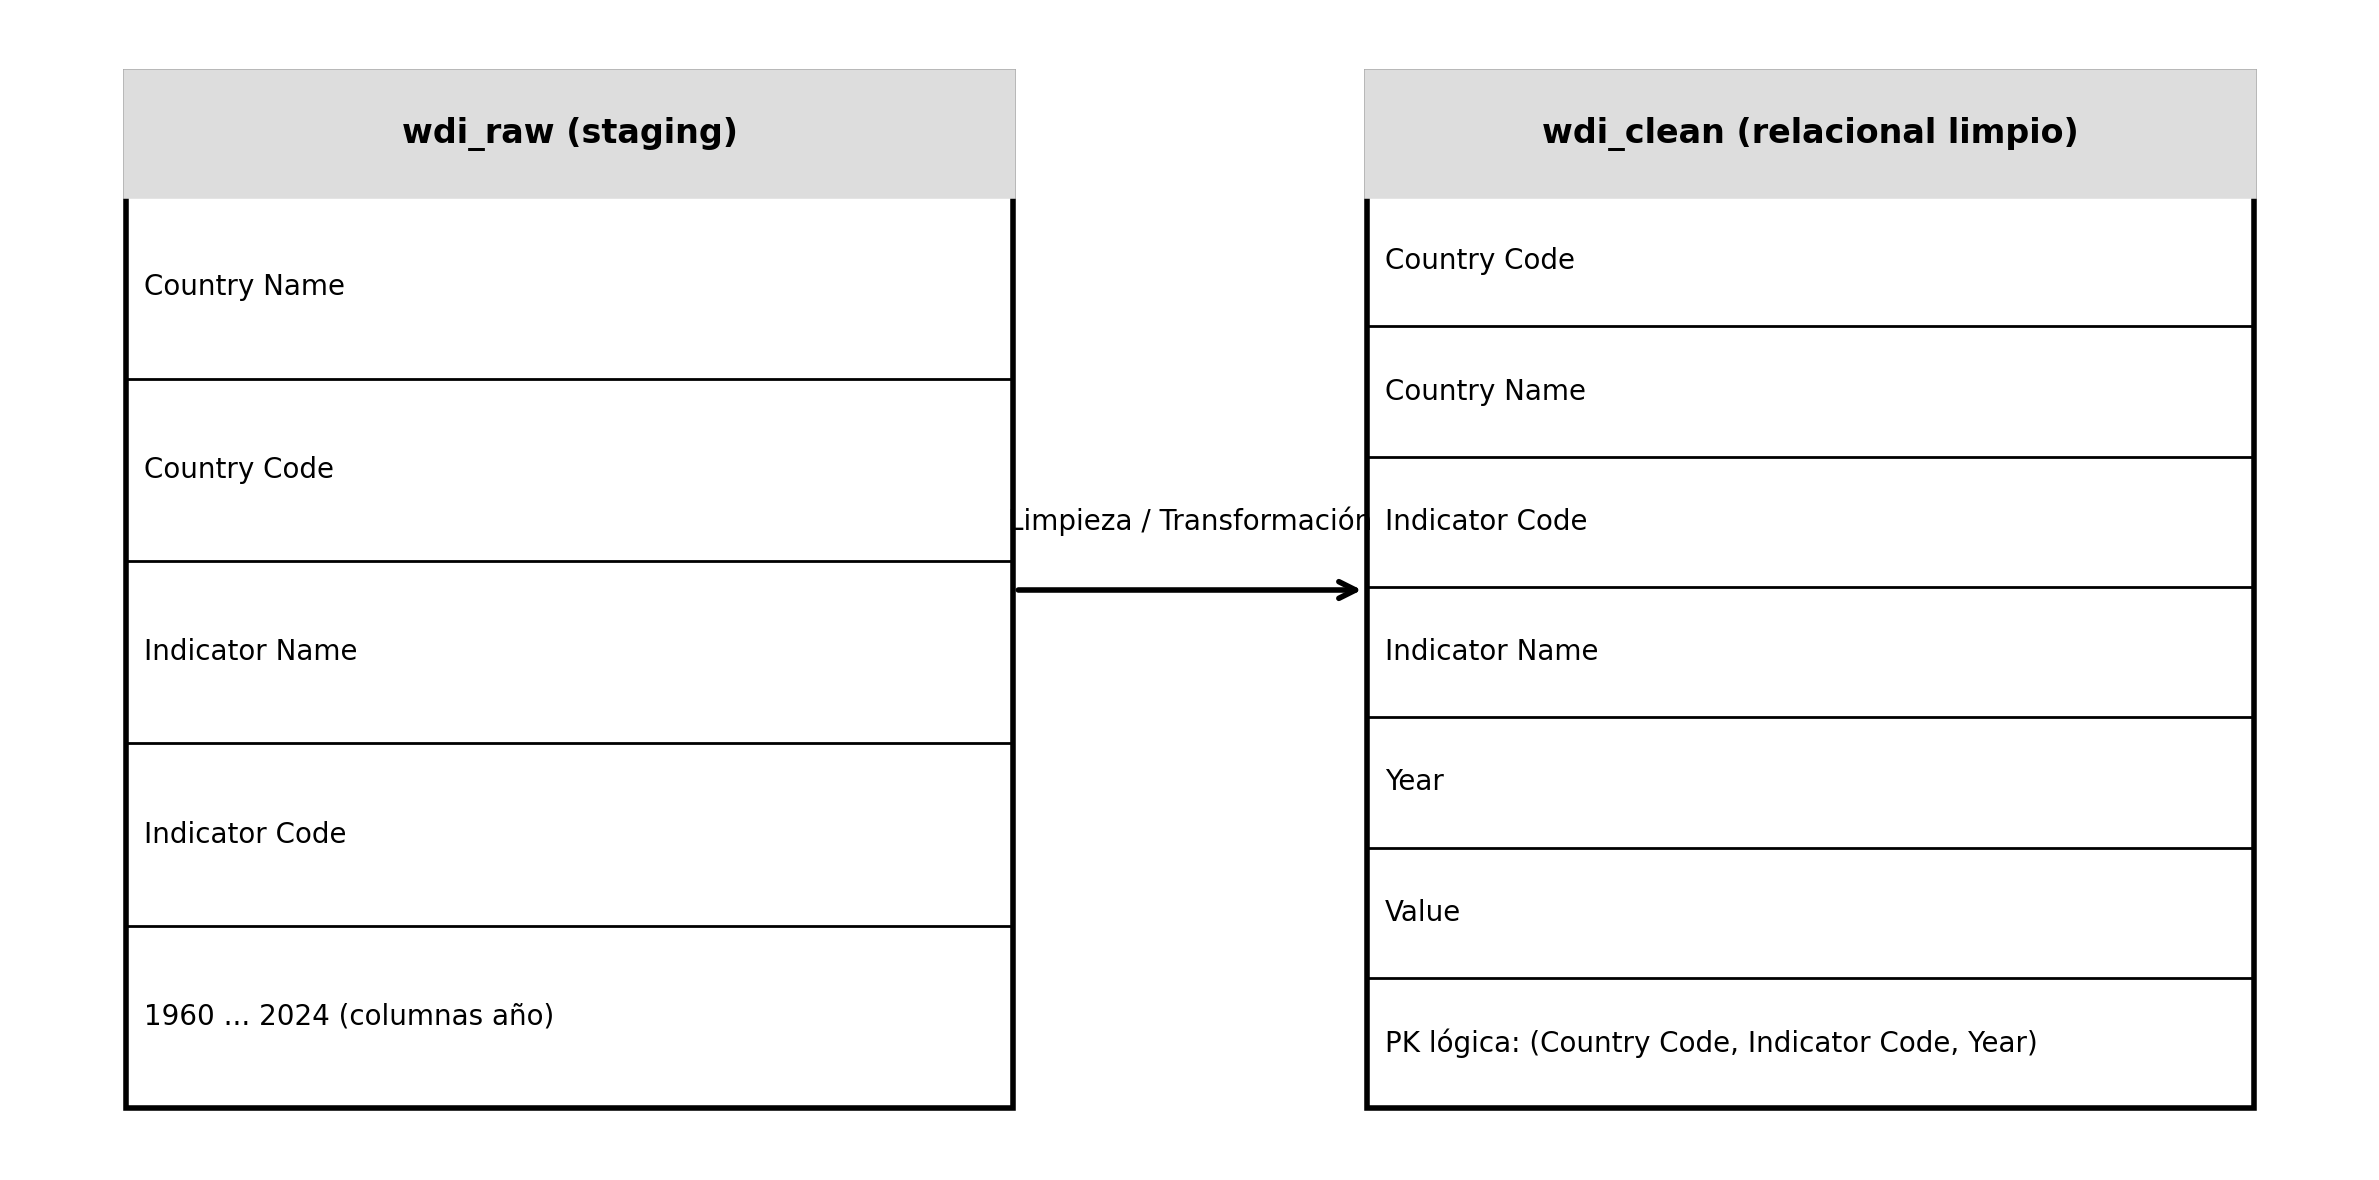

In [20]:
from IPython.display import Image, display
display(Image(filename=ruta_img_relacional))

En este drianagrama se puede ver los siguiente: 

- `wdi_raw` representa el dato casi tal cual llega del CSV (muchas columnas por año).
- `wdi_clean` es el resultado “arreglado” para análisis: dejamos los años en una sola columna `Year` y el valor en `Value`.
- La clave lógica (Country Code, Indicator Code, Year) evita duplicados por combinación país–indicador–año.
- Este paso es clave porque prepara la info para construir un modelo dimensional sin sufrir con 60+ columnas de años.

#14. MODELO EN ESTRELLA

* Diagrama del modelo estrella (Data Warehouse)

Ahora sí viene la parte “pro”: convertir los datos de `wdi_clean` en un **modelo dimensional**.  
La idea del esquema estrella es separar:

- **Dimensiones** (describen el contexto: país, indicador, fecha)
- **Hechos** (el valor medido y sus llaves)

Esto hace que las consultas tipo OLAP (promedios por año, por país, por indicador) sean más rápidas y ordenadas.

In [21]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

ruta_img_estrella = os.path.join(img_dir, "modelo_estrella.png")

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_axis_off()

def draw_box(ax, x, y, w, h, title, lines, title_color="#eeeeee"):
    ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=2))
    header_h = 0.18 * h
    ax.add_patch(Rectangle((x, y + h - header_h), w, header_h, fill=True, color=title_color, linewidth=2))
    ax.text(x + w/2, y + h - header_h/2, title, ha="center", va="center", fontsize=12, fontweight="bold")
    row_h = (h - header_h) / max(len(lines), 1)
    for i, line in enumerate(lines):
        yy = y + h - header_h - (i+1)*row_h
        ax.plot([x, x+w], [yy, yy], color="black", linewidth=1)
        ax.text(x + 0.03*w, yy + row_h/2, line, ha="left", va="center", fontsize=10)

def arrow(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="->", mutation_scale=15, linewidth=2))

# Fact (centro)
fact_lines = [
    "country_key (FK)",
    "indicator_key (FK)",
    "date_key (FK)",
    "Value (medida)"
]
draw_box(ax, 0.40, 0.30, 0.22, 0.35, "fact_wdi", fact_lines, title_color="#ffe6cc")

# Dimensiones alrededor
draw_box(ax, 0.07, 0.55, 0.25, 0.30, "dim_country", [
    "country_key (PK)",
    "country_code",
    "country_name"
], title_color="#d9ead3")

draw_box(ax, 0.68, 0.55, 0.25, 0.30, "dim_indicator", [
    "indicator_key (PK)",
    "indicator_code",
    "indicator_name"
], title_color="#d9ead3")

draw_box(ax, 0.37, 0.02, 0.28, 0.22, "dim_date", [
    "date_key (PK)",
    "Year"
], title_color="#d9ead3")

# Flechas hacia fact
arrow(ax, 0.32, 0.65, 0.40, 0.47)  # country -> fact
arrow(ax, 0.68, 0.65, 0.62, 0.47)  # indicator -> fact
arrow(ax, 0.51, 0.24, 0.51, 0.30)  # date -> fact

plt.tight_layout()
plt.savefig(ruta_img_estrella, dpi=200, bbox_inches="tight")
plt.close()

print("Imagen creada:", ruta_img_estrella)

Imagen creada: ../docs\imagenes\modelo_estrella.png


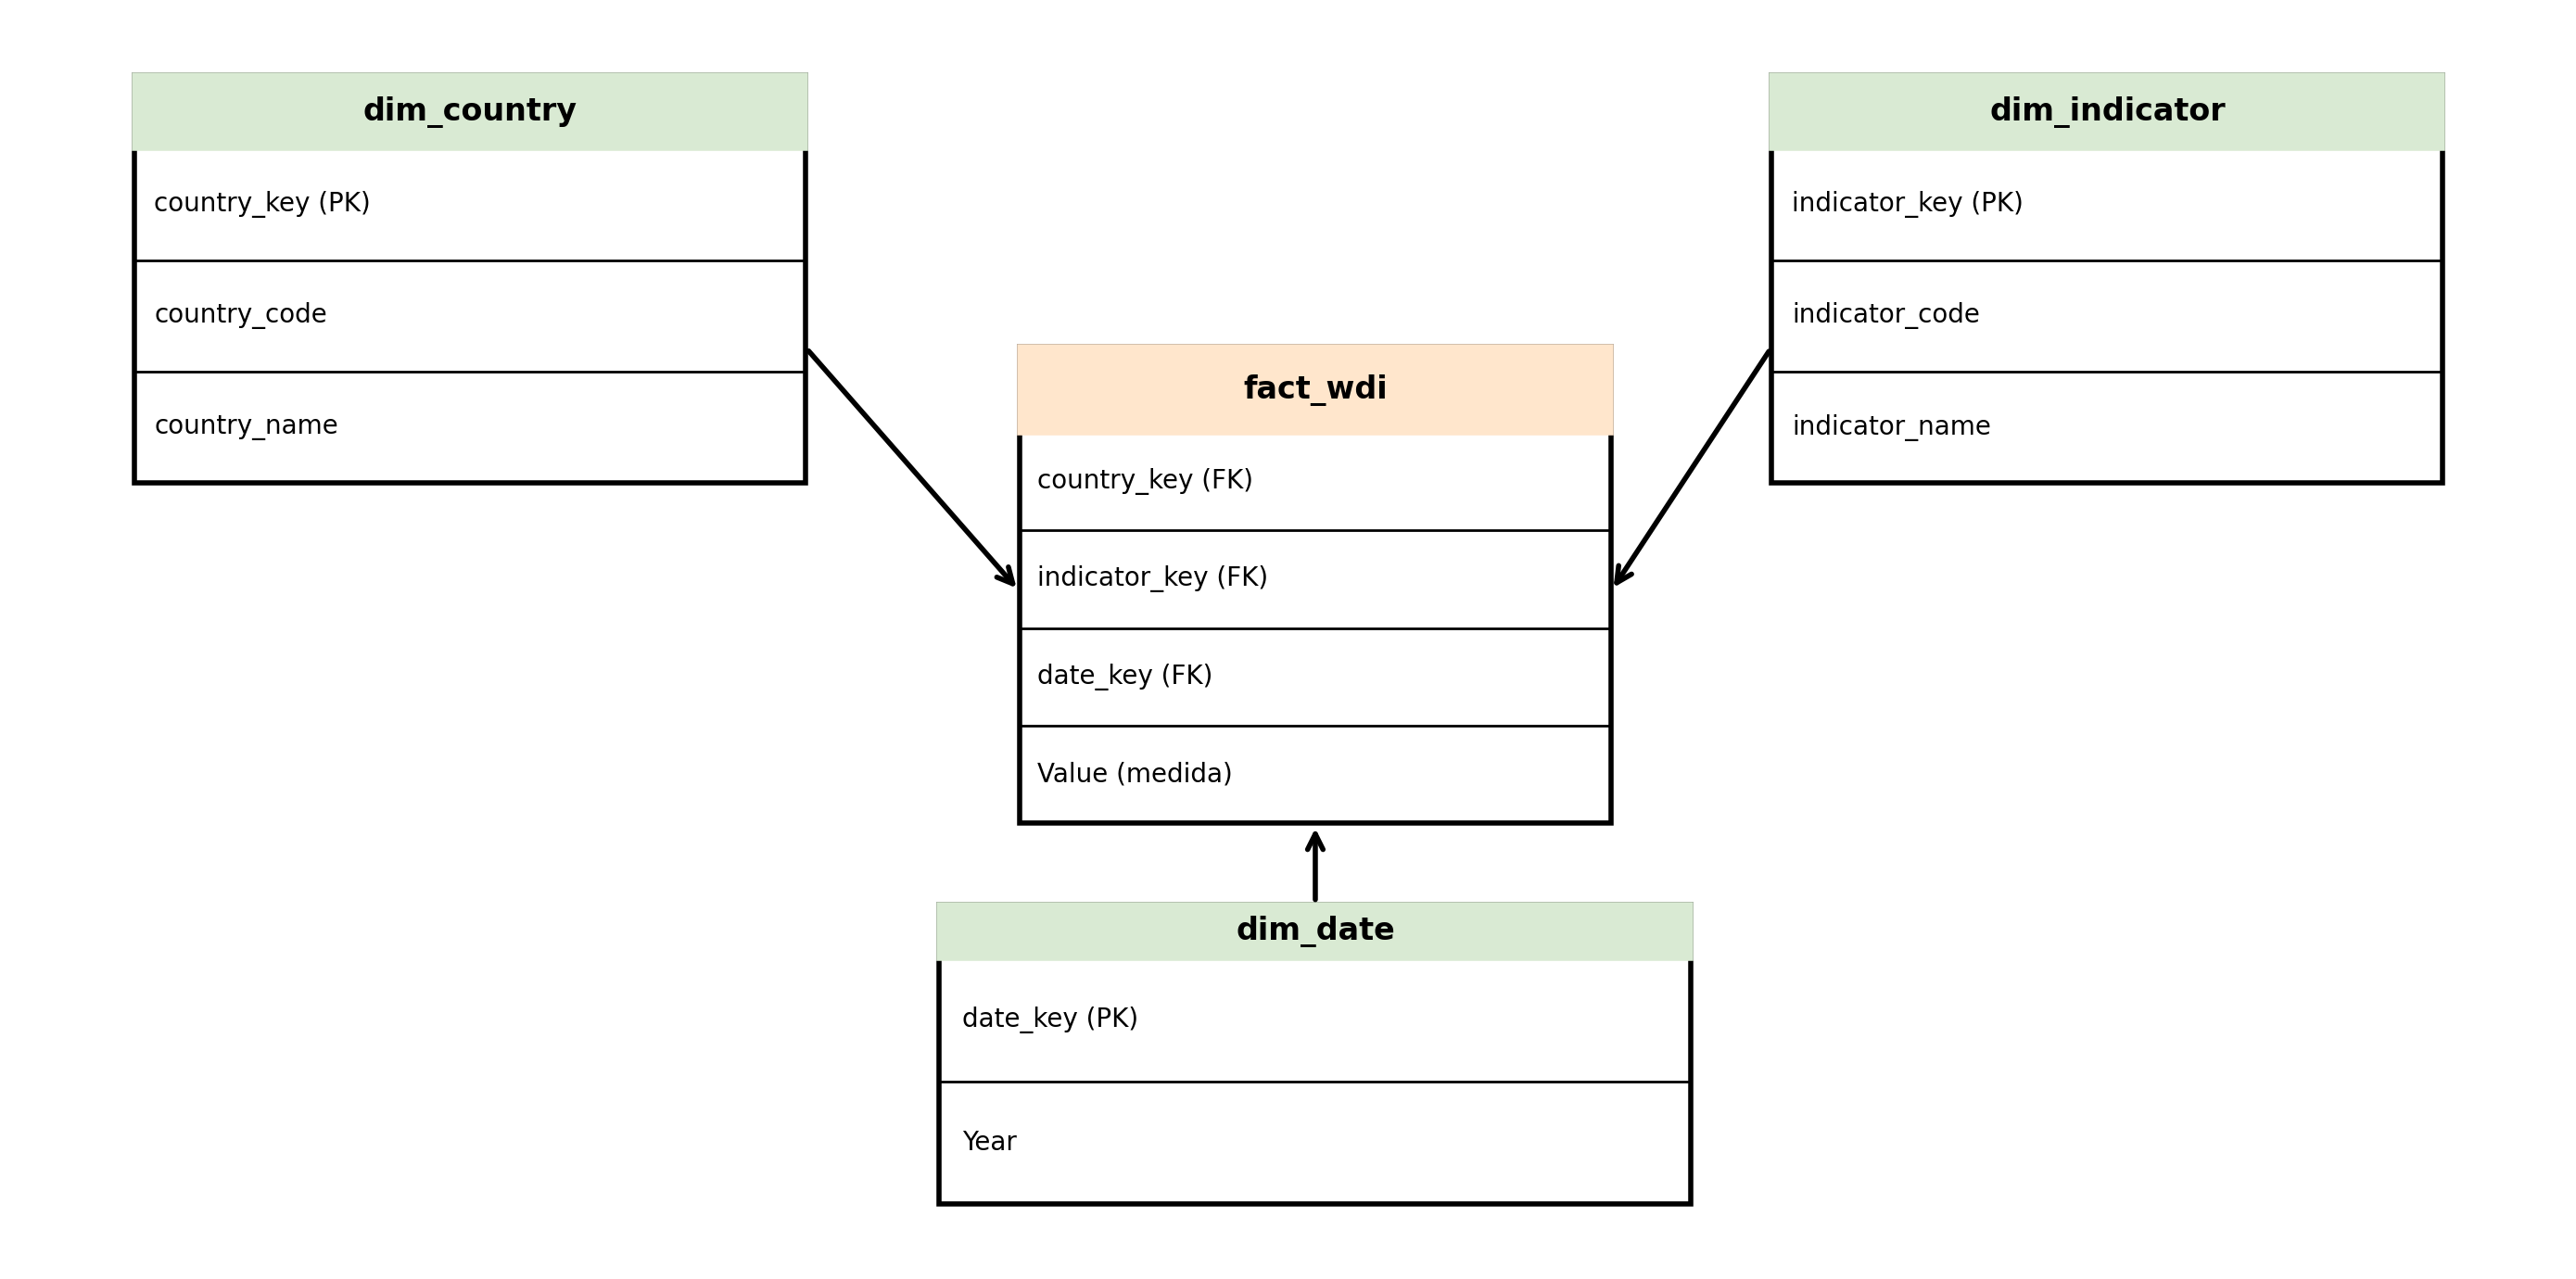

In [22]:
from IPython.display import Image, display
display(Image(filename=ruta_img_estrella))

El diagrma en estrella muestra lo siguiente: 

- **fact_wdi** es la tabla central: aquí está la “medida” (`Value`) y las llaves.
- **dim_country** describe el país (nombre, código).
- **dim_indicator** describe el indicador (qué estamos midiendo).
- **dim_date** organiza el tiempo (año).

Lo bacano de esto es que ahora puedo hacer consultas tipo:
- “Promedio de esperanza de vida por año”
- “Comparar Colombia vs mundo”
- “Top indicadores con más datos”
solo haciendo JOINs simples y rápidos desde la tabla de hechos hacia las dimensiones.

#15. DIAGRAMAS DEL PROYECTO


Antes de seguir con consultas y gráficas, muestro los dos diagramas clave:

- **Modelo relacional (origen):** de dónde sale la data ya limpia (`wdi_clean`).
- **Modelo estrella (DW):** cómo quedó organizado el Data Warehouse (dimensiones + tabla de hechos).

Esto ayuda a que cualquiera entienda el “mapa” del proyecto sin leer todo el código.

Modelo relacional (origen)


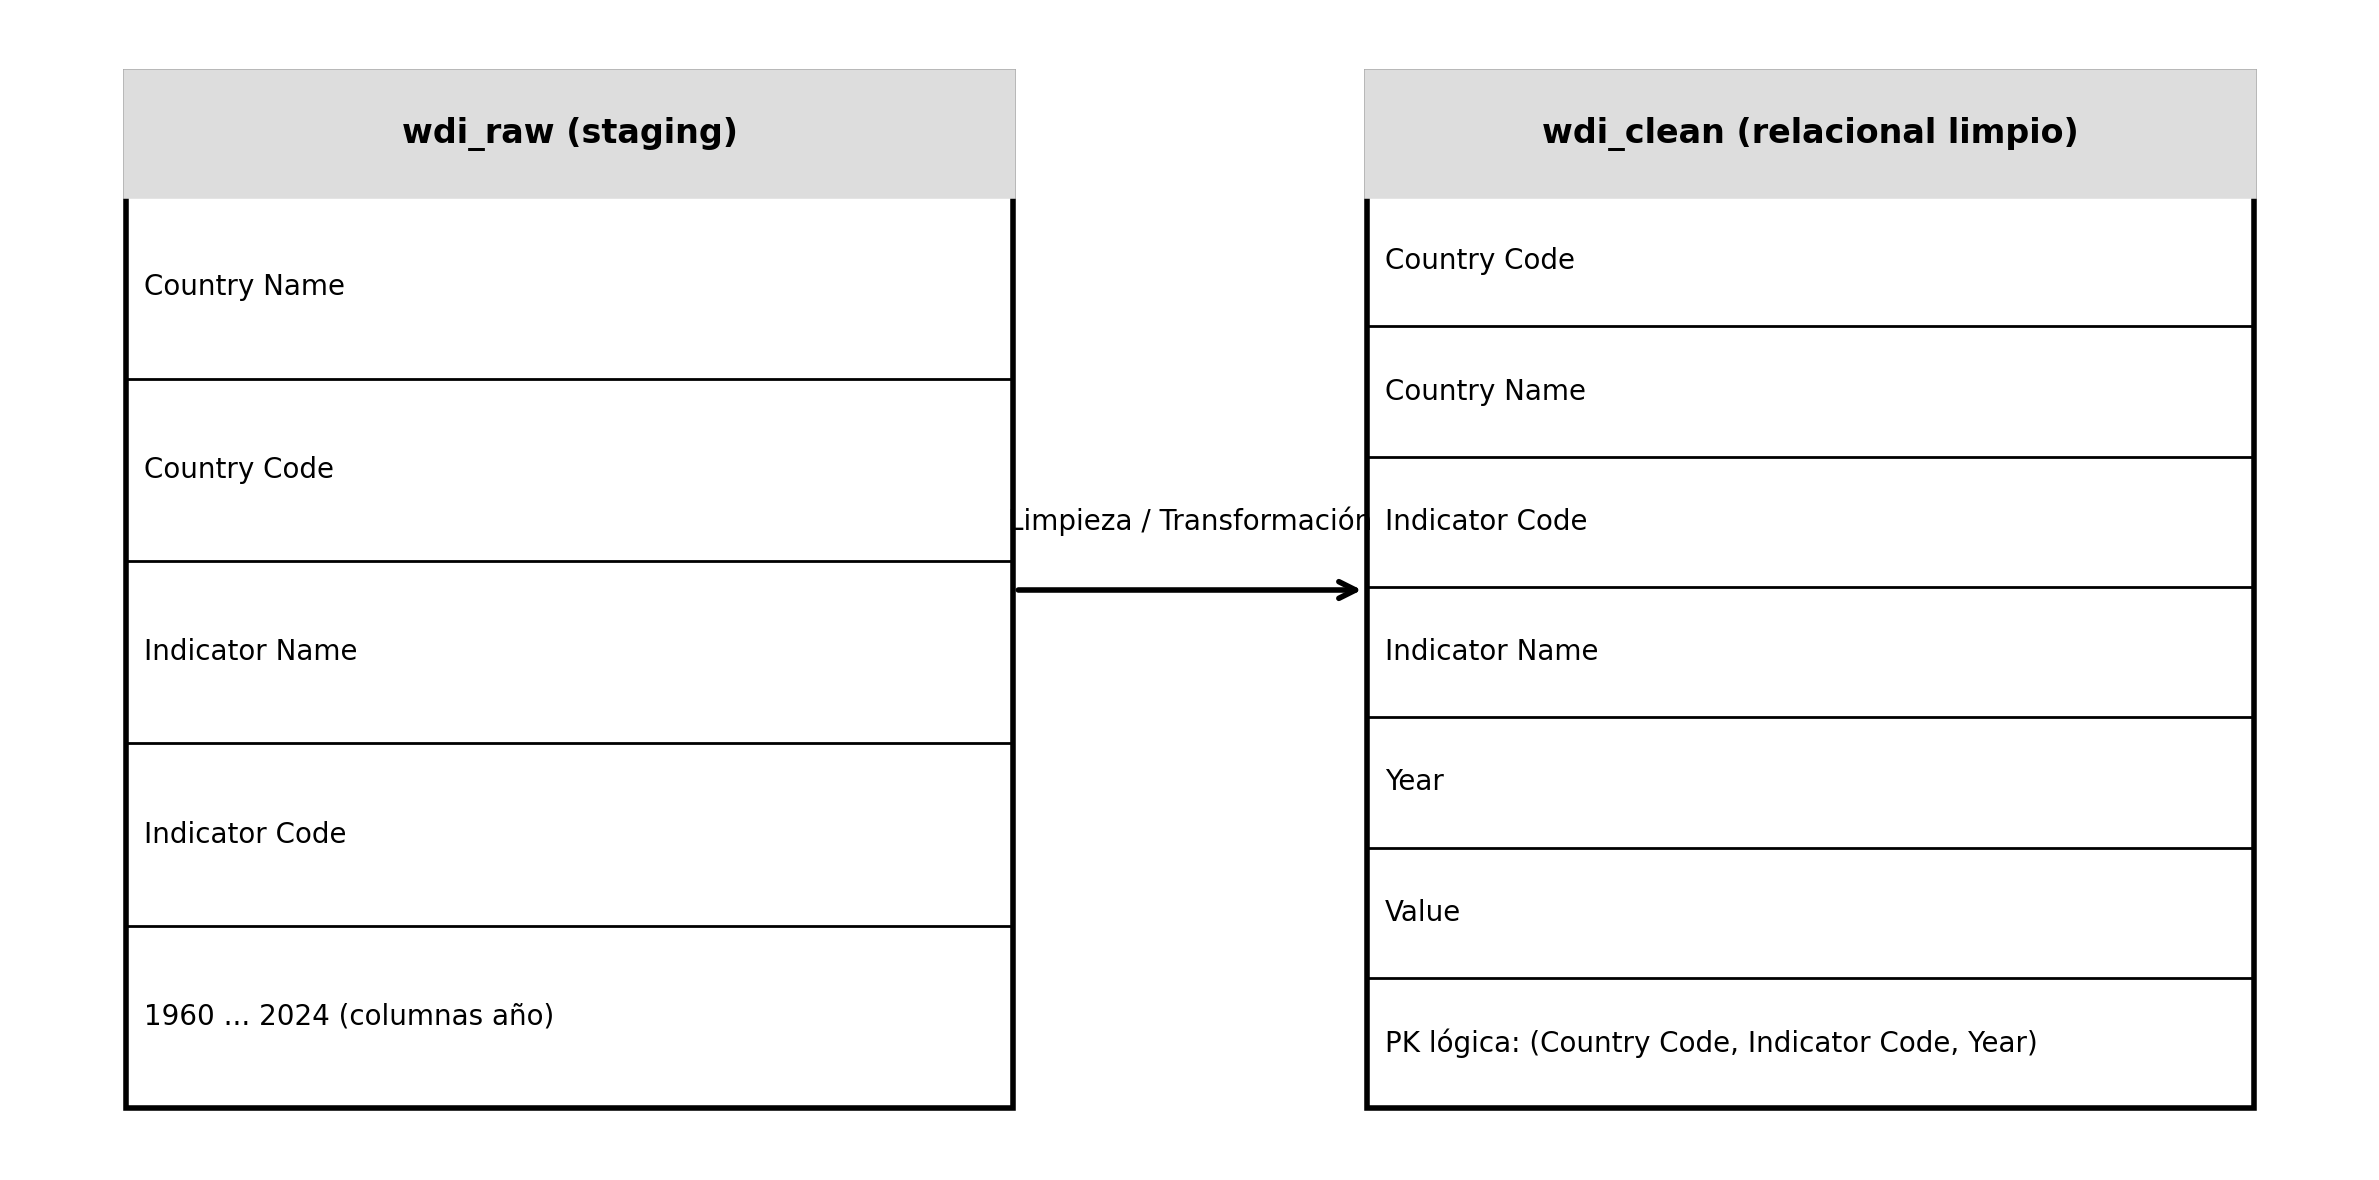

Modelo estrella (Data Warehouse)


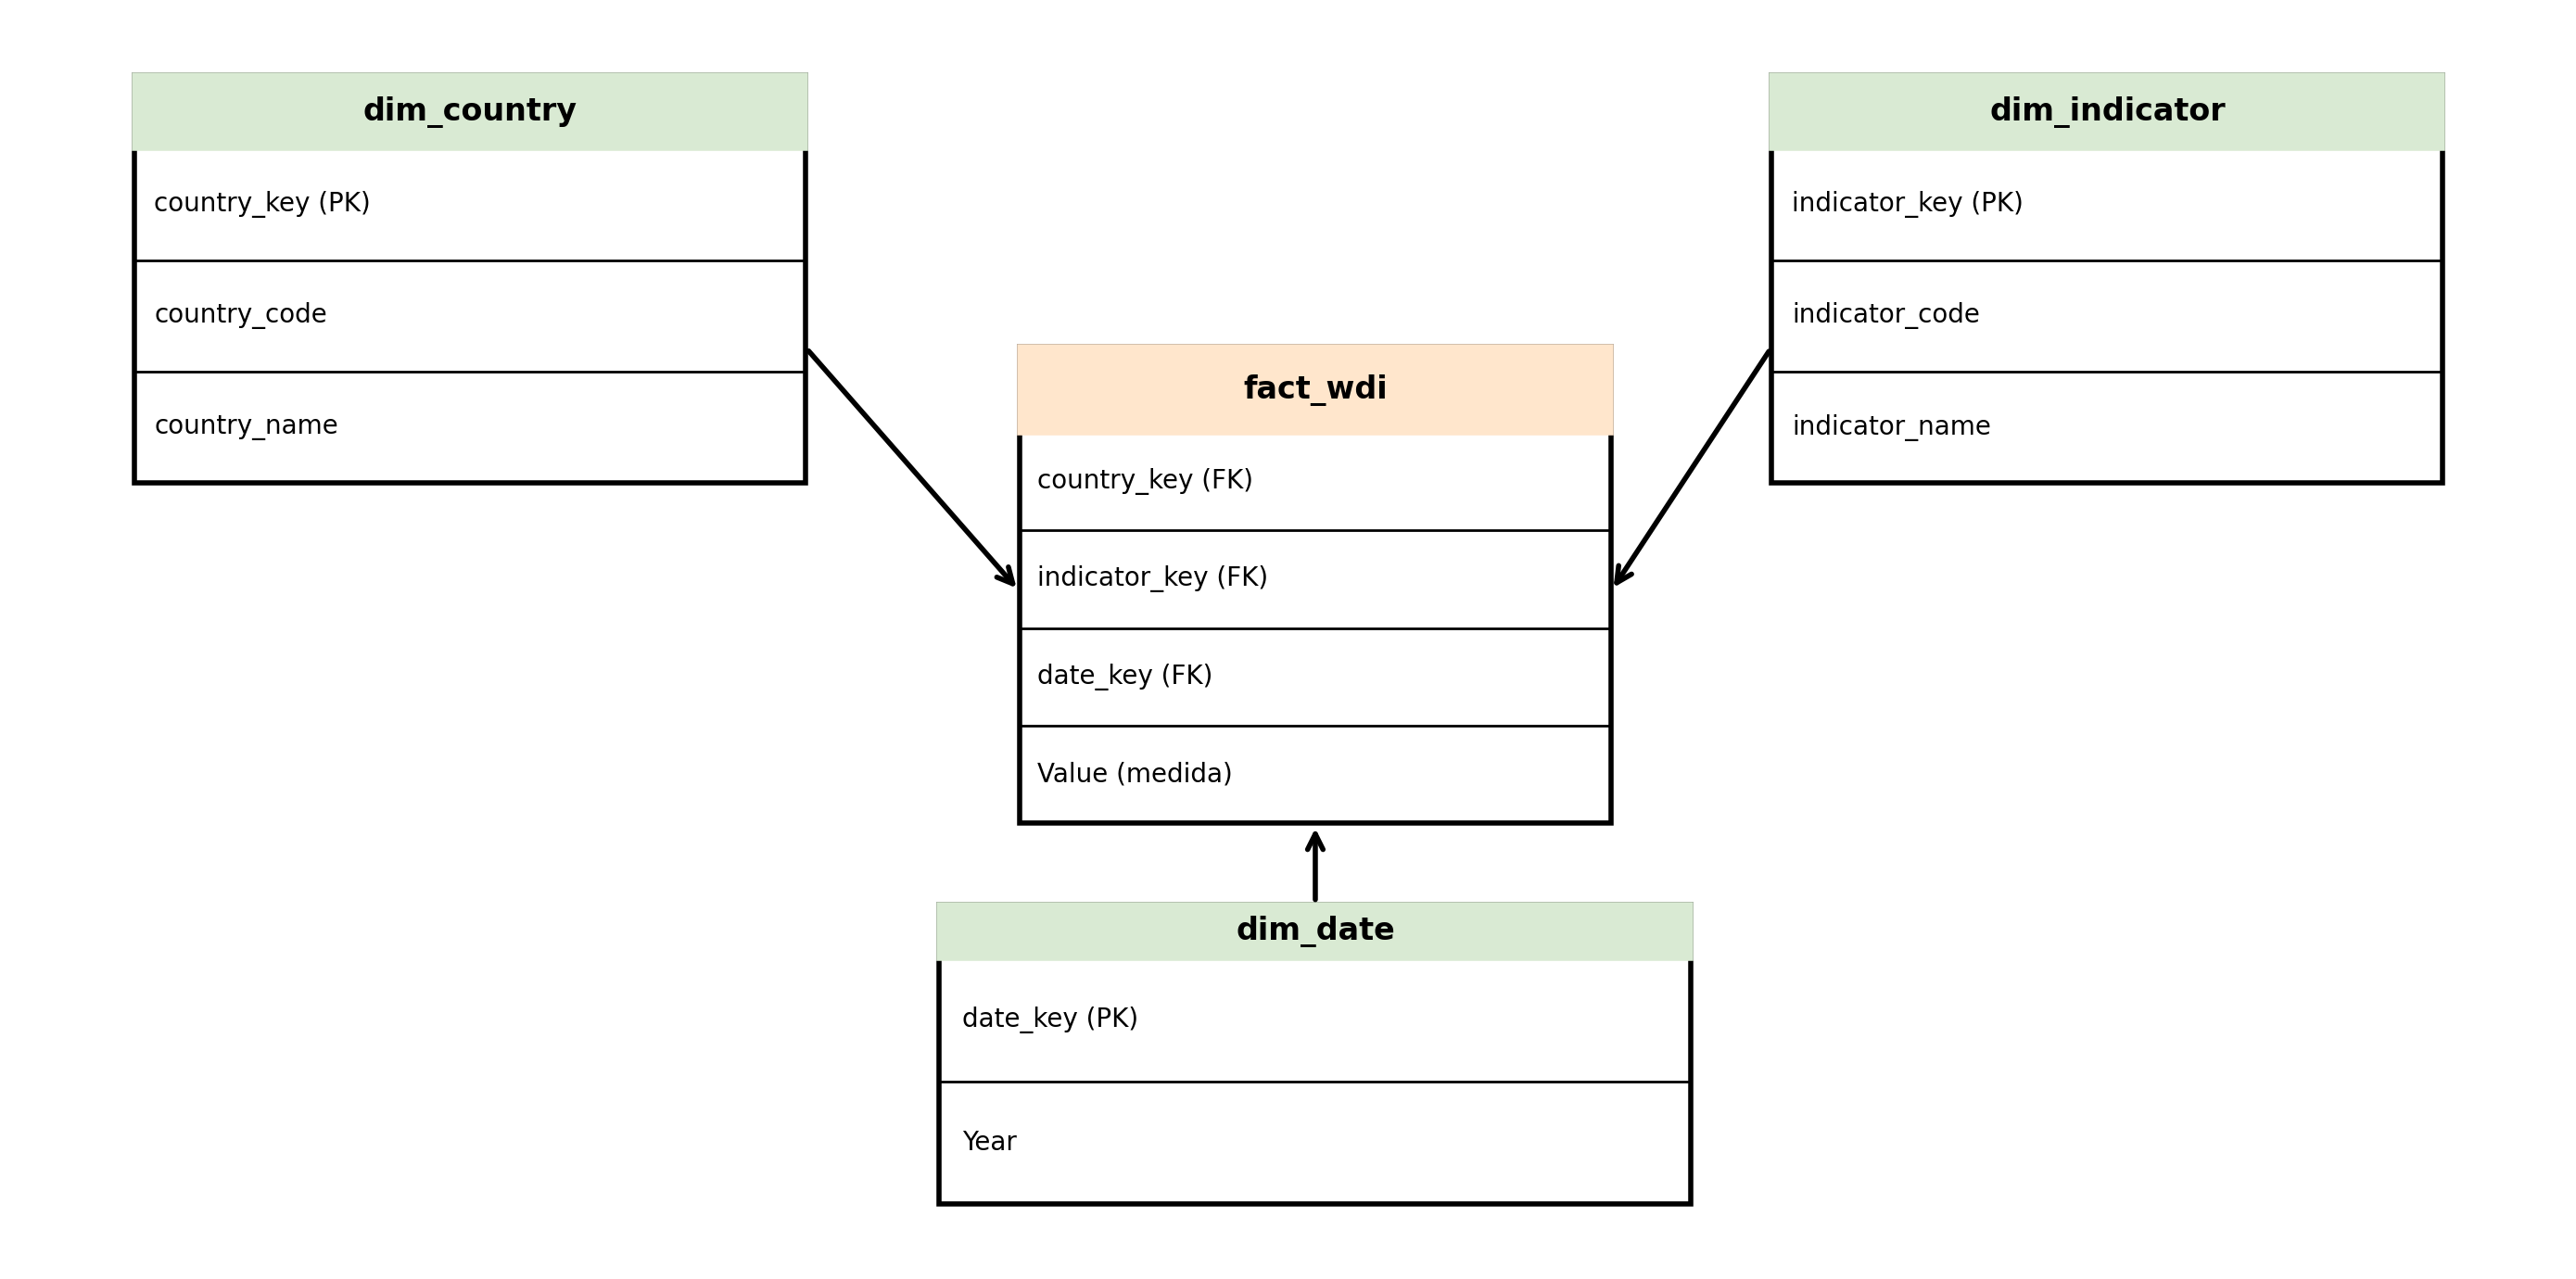

In [23]:
from IPython.display import Image, display

# rutas (ajusta si tus carpetas cambian)
ruta_base = "../"  # notebook está en /notebooks
ruta_rel = ruta_base + "docs/imagenes/modelo_relacional.png"
ruta_star = ruta_base + "docs/imagenes/modelo_estrella.png"

print("Modelo relacional (origen)")
display(Image(filename=ruta_rel))

print("Modelo estrella (Data Warehouse)")
display(Image(filename=ruta_star))

Aqui se ve:

- En el **modelo relacional**, `wdi_clean` tiene la data “lista” en formato largo (Year, Value).
- En el **modelo estrella**, el valor (`Value`) queda en `fact_wdi` y el contexto se reparte en dimensiones:
  país (`dim_country`), indicador (`dim_indicator`) y tiempo (`dim_date`).

# 16. CONSULTA QUE PRUEBE EL MODELO ESTRELA

Aquí hago una consulta que mezcla la tabla de hechos con sus dimensiones.
Es como la “prueba de fuego”: si esto funciona, significa que el modelo estrella está bien conectado.

Voy a traer una muestra de filas con:
- país
- indicador
- año
- valor

Si los campos salen coherentes, entonces el DW está listo para análisis OLAP.

In [24]:

df_join_test = pd.read_sql("""
SELECT 
    c.country_name,
    i.indicator_name,
    d.Year,
    f.Value
FROM fact_wdi f
JOIN dim_country c ON f.country_key = c.country_key
JOIN dim_indicator i ON f.indicator_key = i.indicator_key
JOIN dim_date d ON f.date_key = d.date_key
LIMIT 15;
""", engine)

df_join_test

,country_name,indicator_name,Year,Value
0,Africa Eastern and Southern,"Adolescent fertility rate (births per 1,000 wo...",1960,1.357926e+02
1,Africa Eastern and Southern,Age dependency ratio (% of working-age populat...,1960,8.896779e+01
2,Africa Eastern and Southern,"Age dependency ratio, old (% of working-age po...",1960,5.631545e+00
3,Africa Eastern and Southern,"Age dependency ratio, young (% of working-age ...",1960,8.297010e+01
4,Africa Eastern and Southern,Aquaculture production (metric tons),1960,3.800000e+02
5,Africa Eastern and Southern,Arms exports (SIPRI trend indicator values),1960,2.700000e+07
6,Africa Eastern and Southern,Arms imports (SIPRI trend indicator values),1960,7.400000e+07
7,Africa Eastern and Southern,"Birth rate, crude (per 1,000 people)",1960,4.771077e+01
8,Africa Eastern and Southern,Capture fisheries production (metric tons),1960,1.411417e+06
9,Africa Eastern and Southern,"Charges for the use of intellectual property, ...",1960,5.599998e+06


Analisis del resultado de esta consulta

Esta tabla es como el “examen final” del modelo estrella: si aquí salen bien los datos, significa que las relaciones están bien armadas.

Aqui se ve que cada fila ya viene completa con:

- **country_name** → el nombre del país/región (sale de `dim_country`)
- **indicator_name** → el nombre del i**_**

16.1 Visualización 1 — Tendencia global (Promedio por año) desde SQL

Gráfica 1: Tendencia global por año (desde el DW)

Ahora sí, un análisis OLAP completo:
voy a calcular el promedio global de un indicador por año.

Lo importante:
 el cálculo se hace desde SQL (fact + dims)  
 y luego solo lo dibujo con matplotlib

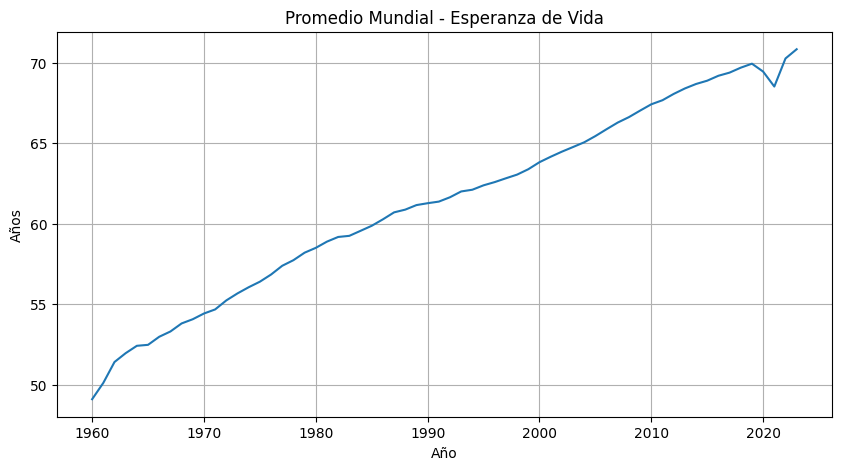

In [25]:
import matplotlib.pyplot as plt

indicador = "Life expectancy at birth, total (years)"

df_global = pd.read_sql(f"""
SELECT 
  d.Year,
  AVG(f.Value) AS avg_value
FROM fact_wdi f
JOIN dim_date d ON f.date_key = d.date_key
JOIN dim_indicator i ON f.indicator_key = i.indicator_key
WHERE i.indicator_name = "{indicador}"
GROUP BY d.Year
ORDER BY d.Year;
""", engine)

plt.figure(figsize=(10,5))
plt.plot(df_global["Year"], df_global["avg_value"])
plt.title("Promedio Mundial - Esperanza de Vida")
plt.xlabel("Año")
plt.ylabel("Años")
plt.grid(True)
plt.show()

La línea va subiendo casi todo el tiempo, lo que básicamente dice:  
“En promedio, la gente en el mundo empezó a vivir más años con el paso del tiempo”.

Se nota una bajada cerca de 2020, que puede estar relacionada con eventos globales fuertes (como la pandemia), y luego vuelve a subir.

16.2 Visualización 2 — Mujeres vs Hombres (comparación en una misma gráfica) desde SQL

Aquí comparo dos indicadores en la misma gráfica:
- Esperanza de vida mujeres
- Esperanza de vida hombres

Esto queda súper bien porque:
- es claro visualmente
- usa el DW de verdad
- y está conectado con ODS 3 (Salud y bienestar)

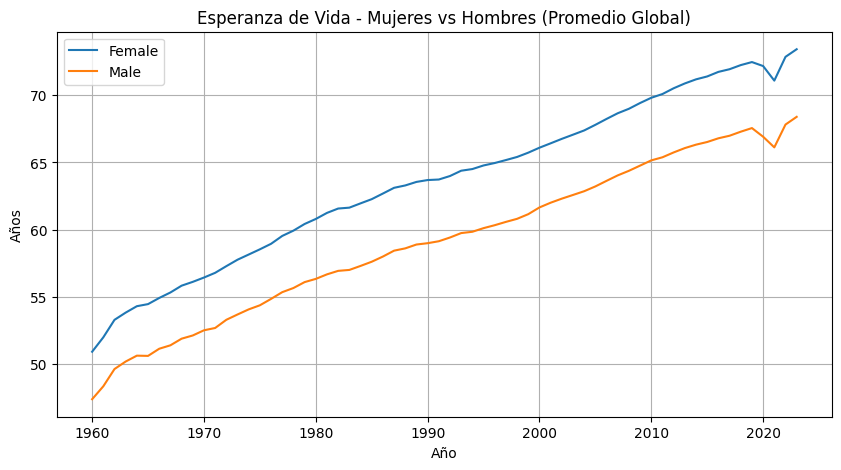

In [26]:
import matplotlib.pyplot as plt

ind_f = "Life expectancy at birth, female (years)"
ind_m = "Life expectancy at birth, male (years)"

df_gender = pd.read_sql(f"""
SELECT 
  d.Year,
  i.indicator_name,
  AVG(f.Value) AS avg_value
FROM fact_wdi f
JOIN dim_date d ON f.date_key = d.date_key
JOIN dim_indicator i ON f.indicator_key = i.indicator_key
WHERE i.indicator_name IN ("{ind_f}", "{ind_m}")
GROUP BY d.Year, i.indicator_name
ORDER BY d.Year;
""", engine)

# pivot para graficar fácil
df_pivot = df_gender.pivot(index="Year", columns="indicator_name", values="avg_value").reset_index()

plt.figure(figsize=(10,5))
plt.plot(df_pivot["Year"], df_pivot[ind_f], label="Female")
plt.plot(df_pivot["Year"], df_pivot[ind_m], label="Male")
plt.title("Esperanza de Vida - Mujeres vs Hombres (Promedio Global)")
plt.xlabel("Año")
plt.ylabel("Años")
plt.grid(True)
plt.legend()
plt.show()

Casi siempre la línea de **mujeres** está por encima de la de **hombres**.
Eso significa que, en promedio, las mujeres tienden a vivir más años.

La diferencia no es gigante, pero se mantiene en el tiempo, y eso ya es un insight clarito para un reporte.

16.3 Visualización 3 — Colombia vs Promedio Mundial  desde SQL

Esta comparación es de las mejor porque contextualiza.

Voy a tomar el mismo indicador (esperanza de vida total) y comparar:
- Colombia
- Promedio mundial

Así no solo digo “sube”, sino “¿Colombia está arriba o abajo del promedio mundial?”

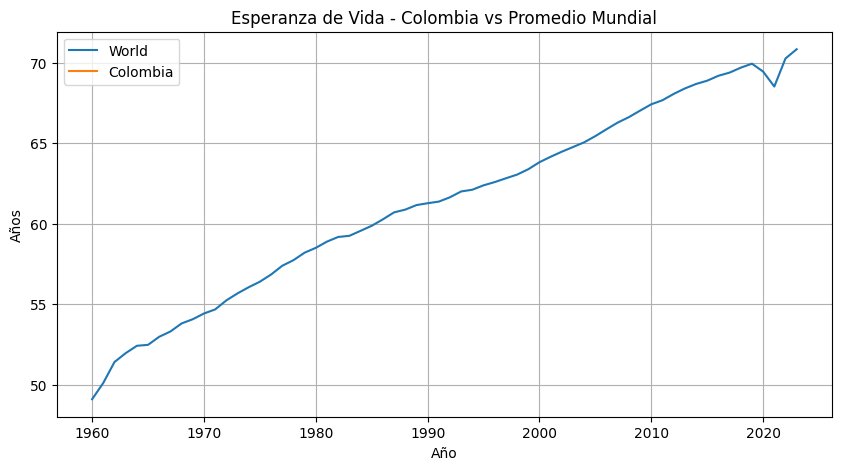

In [27]:
import matplotlib.pyplot as plt

indicador = "Life expectancy at birth, total (years)"
country_code = "COL"

df_col = pd.read_sql(f"""
SELECT 
  d.Year,
  AVG(f.Value) AS avg_value
FROM fact_wdi f
JOIN dim_date d ON f.date_key = d.date_key
JOIN dim_indicator i ON f.indicator_key = i.indicator_key
JOIN dim_country c ON f.country_key = c.country_key
WHERE i.indicator_name = "{indicador}"
  AND c.country_code = "{country_code}"
GROUP BY d.Year
ORDER BY d.Year;
""", engine)

df_world = pd.read_sql(f"""
SELECT 
  d.Year,
  AVG(f.Value) AS avg_value
FROM fact_wdi f
JOIN dim_date d ON f.date_key = d.date_key
JOIN dim_indicator i ON f.indicator_key = i.indicator_key
WHERE i.indicator_name = "{indicador}"
GROUP BY d.Year
ORDER BY d.Year;
""", engine)

plt.figure(figsize=(10,5))
plt.plot(df_world["Year"], df_world["avg_value"], label="World")
plt.plot(df_col["Year"], df_col["avg_value"], label="Colombia")
plt.title("Esperanza de Vida - Colombia vs Promedio Mundial")
plt.xlabel("Año")
plt.ylabel("Años")
plt.grid(True)
plt.legend()
plt.show()

Esta gráfica sirve para ubicar a Colombia en el mapa.

Si la línea de Colombia está arriba del mundo, significa que el país va mejor que el promedio.
Si está abajo, va por debajo.

Lo bueno es que esto ya es un análisis con contexto, no solo una tendencia general.